# Reddit dataset - basic metrics

Dataset = the two parquet files in `data/processed/combined`.
Nothing loads full data — sizes from stat(), rows from the parquet footer, category counts streamed per row-group (one column).

In [1]:
from collections import Counter
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

DATA = Path.cwd().parent / "data" / "processed" / "combined"

FILES = {
    "submissions": DATA / "submissions_trump.parquet",
    "comments": DATA / "comments_trump.parquet"
}

files = {k: pq.ParquetFile(p) for k, p in FILES.items()}

## size, rows, breakdown by type

In [2]:
overview = pd.DataFrame(
    {
        "size_MB": [FILES[k].stat().st_size / 1024**2 for k in files],
        "rows": [f.metadata.num_rows for f in files.values()],
    },
    index=list(files),
)
overview["rows_%"] = 100 * overview["rows"] / overview["rows"].sum()
overview.loc["TOTAL"] = overview.sum()
overview.round(1)

,size_MB,rows,rows_%
submissions,246.3,513848.0,10.0
comments,1319.2,4601620.0,90.0
TOTAL,1565.5,5115468.0,100.0


A plain read_parquet would need ~7.3 GB RAM for comments, ~8.5 GB for both files (measured below from a sample, extrapolated by row count).

In [3]:
def est_pandas_gb(name, batch=20_000):
    f = files[name]
    # one batch from the start of every row group so different periods are sampled
    sample = pd.concat(
        next(f.iter_batches(batch_size=batch, row_groups=[i])).to_pandas()
        for i in range(f.metadata.num_row_groups)
    )
    per_row = sample.memory_usage(deep=True).sum() / len(sample)
    return {"sample_rows": len(sample), "bytes_per_row": per_row,
            "est_pandas_GB": per_row * f.metadata.num_rows / 1024**3}


est = pd.DataFrame({k: est_pandas_gb(k) for k in files}).T
est.loc["TOTAL", "est_pandas_GB"] = est["est_pandas_GB"].sum()
est.round(2)

,sample_rows,bytes_per_row,est_pandas_GB
submissions,20000.0,2434.96,1.17
comments,100000.0,1701.35,7.29
TOTAL,NaN,NaN,8.46


## counts per category

Two categorical columns present in both files: `subreddit` and `source_month`.
Counted row-group by row-group so the 1.4 GB comments file never lands in RAM at once.

In [4]:
def count_by(name, column):
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        counts.update(f.read_row_group(i, columns=[column])[column].to_pylist())
    return pd.Series(counts, name=name).sort_values(ascending=False)


by_month = pd.concat([count_by(k, "source_month") for k in files], axis=1).sort_index()
by_month.style.format("{:,}").background_gradient(cmap="Blues")

,submissions,comments
2017-01,"39,253","378,728"
2017-02,"38,588","321,216"
2017-03,"33,887","290,558"
2017-04,"26,421","203,596"
2017-05,"35,318","297,488"
2017-06,"26,793","264,068"
2018-01,"28,963","256,804"
2018-02,"23,134","196,872"
2018-03,"26,994","225,168"
2018-04,"24,080","216,950"


distinct subreddits: 6


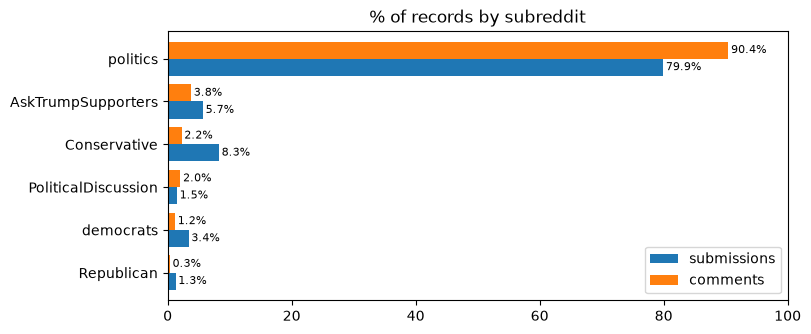

In [5]:
by_sub = pd.concat([count_by(k, "subreddit") for k in files], axis=1).fillna(0).astype(int)
print(f"distinct subreddits: {len(by_sub):,}")
share = 100 * by_sub / by_sub.sum()
ax = share.sort_values("comments").plot.barh(figsize=(8, 3.5), width=0.8, xlim=(0, 100), title="% of records by subreddit")
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)

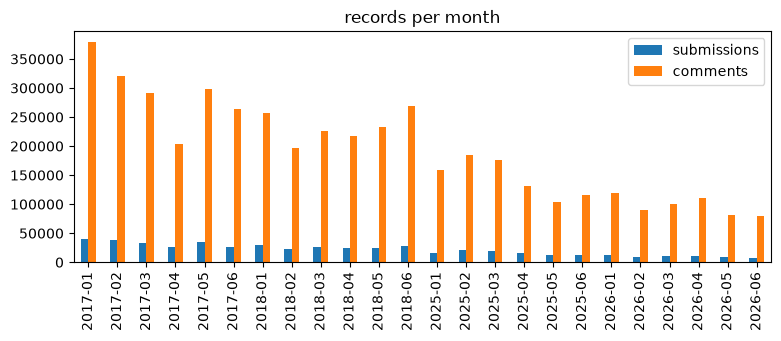

In [6]:
by_month.plot.bar(figsize=(9, 3), title="records per month");

## duplicates

Reddit `id` is unique per comment / per submission, so a repeated id = same record collected twice. Only the `id` column is read (~50 MB).

In [7]:
import pyarrow.compute as pc


def dup_check(name):
    ids = files[name].read(columns=["id"])["id"]
    valid = len(ids) - ids.null_count
    return {"rows": len(ids), "null_ids": ids.null_count, "duplicate_rows": valid - pc.count_distinct(ids).as_py()}


pd.DataFrame({k: dup_check(k) for k in files}).T

,rows,null_ids,duplicate_rows
submissions,513848,0,0
comments,4601620,0,0


## head

First 3 rows, transposed (132 / 87 columns). Note: first rows are all 2017-01.

In [8]:
import pyarrow as pa

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 60):
    for k, f in files.items():
        print(k)
        display(next(f.iter_batches(batch_size=3)).to_pandas().T)

submissions


,0,1,2
score,1,266,1
suggested_sort,NaN,NaN,NaN
author_flair_css_class,NaN,NaN,NaN
media,NaN,NaN,NaN
permalink,/r/politics/comments/5lch1i/trump_ditches_press_pool_to_...,/r/politics/comments/5lci8r/putin_won_2016_but_russia_ha...,/r/politics/comments/5lciy3/this_photo_of_a_trump_billbo...
selftext,NaN,NaN,[deleted]
archived,False,False,False
url,http://www.cnn.com/2016/12/31/politics/donald-trump-pres...,https://www.washingtonpost.com/world/europe/putin-won-20...,http://m.huffpost.com/us/entry/us_586813c3e4b0d9a5945bb091
subreddit,politics,politics,politics
subreddit_id,t5_2cneq,t5_2cneq,t5_2cneq


comments


,0,1,2
subreddit_id,t5_2cneq,t5_2cneq,t5_2cneq
retrieved_on,1485679713,1485679725,1485679726
author_flair_css_class,us-flag,minnesota-flag,us-flag
author_flair_text,America,Minnesota,America
controversiality,1,0,1
link_id,t3_5lbx9q,t3_5lbdw1,t3_5lbx9q
score,4,7,0
author,GaryRuppert,Kichigai,GaryRuppert
subreddit,politics,politics,politics
body,Kind of a shame for Bill Clinton that he's determined to...,"Please, McCain has done more to try and unite the countr...",remember when Dems said Trump had no GOTV operation?


## missing values

Null counts straight from the parquet footer (no data read). NaN in the table = column not in that file.

In [10]:
def null_counts(name):
    f = files[name]
    md = f.metadata
    out = {}
    for j in range(md.num_columns):
        stats = [md.row_group(i).column(j).statistics for i in range(md.num_row_groups)]
        c = md.schema.column(j).name
        if all(s is not None and s.has_null_count for s in stats):
            out[c] = sum(s.null_count for s in stats)
        else:  # no footer stats (all-null columns) -> read it, cheap
            out[c] = f.read(columns=[c])[c].null_count
    s = pd.Series(out)
    return pd.DataFrame({"nulls": s, "null_%": (100 * s / md.num_rows).round(1)})


nulls = pd.concat({k: null_counts(k) for k in files}, axis=1)
all_null = {k: nulls.index[nulls[(k, "nulls")] == files[k].metadata.num_rows].tolist() for k in files}
for k, cols in all_null.items():
    print(f"{k}: {len(cols)} columns 100% null (drop):", cols)
with pd.option_context("display.max_rows", None):
    display(nulls[(nulls.xs("null_%", axis=1, level=1) > 0).any(axis=1)].sort_values(("comments", "null_%")))

submissions: 20 columns 100% null (drop): ['view_count', 'approved_at_utc', 'banned_at_utc', 'approved_by', 'banned_by', 'category', 'content_categories', 'likes', 'num_reports', 'post_categories', 'report_reasons', 'discussion_type', 'mod_note', 'mod_reason_by', 'mod_reason_title', 'removed_by', 'top_awarded_type', 'location_lat', 'location_long', 'location_name']
comments: 15 columns 100% null (drop): ['approved_at_utc', 'banned_at_utc', 'approved_by', 'banned_by', 'likes', 'num_reports', 'report_reasons', 'mod_note', 'mod_reason_by', 'mod_reason_title', 'top_awarded_type', 'associated_award', 'collapsed_because_crowd_control', 'comment_type', 'unrepliable_reason']


submissions          comments       
                                      nulls null_%      nulls null_%
can_gild                           226103.0   44.0   990502.0   21.5
permalink                               0.0    0.0  1755654.0   38.2
subreddit_type                     200260.0   39.0  1755654.0   38.2
is_submitter                            NaN    NaN  1755654.0   38.2
send_replies                       229223.0   44.6  2209330.0   48.0
no_follow                          229223.0   44.6  2209330.0   48.0
archived                                0.0    0.0  2434498.0   52.9
can_mod_post                       300654.0   58.5  2433783.0   52.9
score_hidden                            NaN    NaN  2434498.0   52.9
author_flair_richtext              298073.0   58.0  2888458.0   62.8
author_flair_type                  298073.0   58.0  2888458.0   62.8
mod_reports                        306745.0   59.7  3080217.0   66.9
user_reports                       306745.0   59.7  3080217.0   66.9
saved                              306745.0   59.7  3080217.0   66.9
downs                              306745.0   59.7  3152758.0   68.5
name                               306745.0   59.7  3152758.0   68.5
all_awardings                      354844.0   69.1  3152758.0   68.5
author_is_blocked                  354844.0   69.1  3152758.0   68.5
treatment_tags                     354844.0   69.1  3152758.0   68.5
total_awards_received              354844.0   69.1  3152758.0   68.5
replies                                 NaN    NaN  3152758.0   68.5
collapsed                               NaN    NaN  3152758.0   68.5
gildings                           354844.0   69.1  3152758.0   68.5
awarders                           354844.0   69.1  3152758.0   68.5
subreddit_name_prefixed            327447.0   63.7  3152758.0   68.5
ups                                306745.0   59.7  3152758.0   68.5
author_patreon_flair               357507.0   69.6  3152764.0   68.5
author_premium                     357507.0   69.6  3152764.0   68.5
locked                                  0.0    0.0  3152758.0   68.5
created                            306745.0   59.7  3152758.0   68.5
_meta                              356402.0   69.4  3155599.0   68.6
author_fullname                    335526.0   65.3  3159565.0   68.7
author_flair_text                  400918.0   78.0  3753784.0   81.6
author_flair_css_class             422885.0   82.3  3815637.0   82.9
profile_over_18                         NaN    NaN  4138738.0   89.9
profile_img                             NaN    NaN  4138738.0   89.9
author_flair_text_color            431820.0   84.0  4280028.0   93.0
author_flair_template_id           462518.0   90.0  4283899.0   93.1
rte_mode                           465749.0   90.6  4332984.0   94.2
author_flair_background_color      481245.0   93.7  4477324.0   97.3
body_html                               NaN    NaN  4529079.0   98.4
distinguished                      513445.0   99.9  4559433.0   99.1
author_cakeday                     512513.0   99.7  4587940.0   99.7
collapsed_reason_code                   NaN    NaN  4594517.0   99.8
num_comments                            0.0    0.0  4601174.0  100.0
banned_by                          513848.0  100.0  4601620.0  100.0
over_18                                 0.0    0.0  4601174.0  100.0
quarantine                         127187.0   24.8  4601174.0  100.0
report_reasons                     513848.0  100.0  4601620.0  100.0
removal_reason                     513846.0  100.0  4601595.0  100.0
num_reports                        513848.0  100.0  4601620.0  100.0
likes                              513848.0  100.0  4601620.0  100.0
approved_by                        513848.0  100.0  4601620.0  100.0
mod_reason_by                      513848.0  100.0  4601620.0  100.0
media_metadata                     513602.0  100.0  4600860.0  100.0
mod_note                           513848.0  100.0  4601620.0  100.0
top_awarded_type              

submissions: 20 columns 100% null (drop): ['view_count', 'approved_at_utc', 'banned_at_utc', 'approved_by', 'banned_by', 'category', 'content_categories', 'likes', 'num_reports', 'post_categories', 'report_reasons', 'discussion_type', 'mod_note', 'mod_reason_by', 'mod_reason_title', 'removed_by', 'top_awarded_type', 'location_lat', 'location_long', 'location_name']
comments: 15 columns 100% null (drop): ['approved_at_utc', 'banned_at_utc', 'approved_by', 'banned_by', 'likes', 'num_reports', 'report_reasons', 'mod_note', 'mod_reason_by', 'mod_reason_title', 'top_awarded_type', 'associated_award', 'collapsed_because_crowd_control', 'comment_type', 'unrepliable_reason']


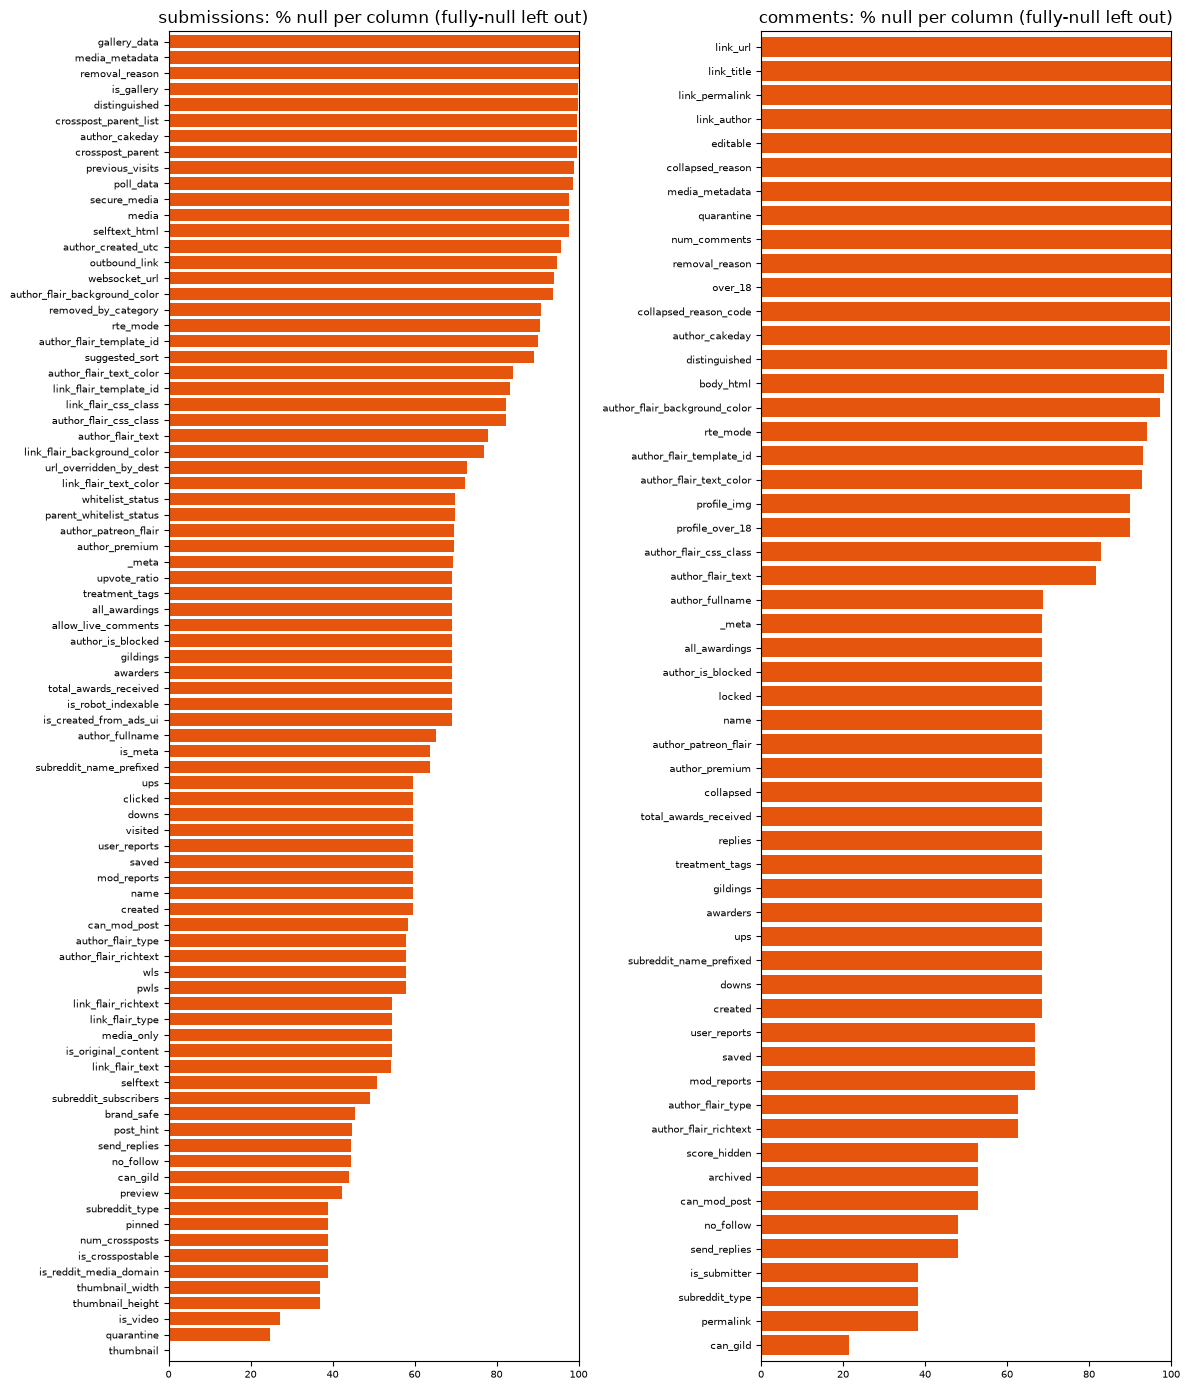

In [15]:
def null_counts(name):
    f = files[name]
    md = f.metadata
    out = {}
    for j in range(md.num_columns):
        stats = [md.row_group(i).column(j).statistics for i in range(md.num_row_groups)]
        c = md.schema.column(j).name
        if all(s is not None and s.has_null_count for s in stats):
            out[c] = sum(s.null_count for s in stats)
        else:  # no footer stats (all-null columns) -> read it, cheap
            out[c] = f.read(columns=[c])[c].null_count
    s = pd.Series(out)
    return pd.DataFrame({"nulls": s, "null_%": (100 * s / md.num_rows).round(1)})


nulls = pd.concat({k: null_counts(k) for k in files}, axis=1)
all_null = {k: nulls.index[nulls[(k, "nulls")] == files[k].metadata.num_rows].tolist() for k in files}
for k, cols in all_null.items():
    print(f"{k}: {len(cols)} columns 100% null (drop):", cols)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 14))
for ax, k in zip(axes, files):
    s = nulls[(k, "null_%")].drop(all_null[k]).dropna()
    s[s > 0].sort_values().plot.barh(ax=ax, width=0.8, xlim=(0, 100), color="#e6550d", fontsize=7,
                                      title=f"{k}: % null per column (fully-null left out)")
fig.tight_layout()

In [11]:
# nulls come in whole-month blocks (field missing from that period's dump) -> % null per month
# red = missing, white = present; rows sorted so columns with the same gap pattern sit together
def null_pct_by_month(name, cols):
    f = files[name]
    month = f.read(columns=["source_month"])["source_month"].to_pandas()
    df = pd.DataFrame({c: f.read(columns=[c])[c].is_null().to_pandas().groupby(month).mean() * 100 for c in cols}).T.round().astype(int)
    return df.sort_values(list(df.columns))


for k in files:
    cols = nulls.index[(nulls[(k, "nulls")] > 0) & (nulls[(k, "nulls")] < files[k].metadata.num_rows)]
    print(k)
    display(null_pct_by_month(k, cols).style.background_gradient(cmap="Reds", vmin=0, vmax=100, axis=None)
            .set_table_styles([{"selector": "td, th", "props": "font-size: 9px; padding: 1px 4px"}]))

submissions


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
thumbnail,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
brand_safe,0,0,0,0,0,0,0,0,0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
quarantine,0,0,0,0,0,0,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0
preview,59,57,54,54,54,49,45,44,46,48,46,45,22,24,19,19,22,37,37,23,18,17,18,17
post_hint,59,57,54,54,54,49,45,44,46,48,46,45,23,25,21,22,30,63,83,41,18,17,18,17
link_flair_text,59,65,64,63,65,58,72,73,70,74,73,75,37,38,38,40,39,39,8,7,7,6,6,6
selftext,71,71,74,72,73,74,75,76,77,75,75,76,0,0,0,0,0,0,0,0,0,0,0,0
author_flair_text,84,83,86,80,80,82,82,80,81,100,100,77,67,70,69,67,63,61,62,61,61,60,59,57
author_flair_css_class,86,84,88,81,81,83,83,81,82,100,100,91,75,76,77,76,73,71,71,72,70,70,69,69
link_flair_css_class,90,91,92,92,90,90,83,83,79,83,83,85,64,64,68,72,73,71,74,76,78,75,77,78


comments


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
author_flair_text,86,84,85,84,82,81,80,81,78,79,78,79,83,83,82,81,82,81,81,82,80,81,79,80
author_flair_css_class,87,84,86,84,82,82,80,82,80,80,79,80,86,85,85,84,84,84,84,84,83,83,81,83
distinguished,99,99,99,99,99,100,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99,99
can_gild,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
permalink,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
subreddit_type,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
is_submitter,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
no_follow,100,100,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
send_replies,100,100,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
mod_reports,100,100,100,100,100,100,100,100,68,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
# pseudo-missing: real strings that mean "no value" — footer null counts don't see them
PSEUDO = pa.array(["", "nan", "None", "NaN", "[deleted]", "[removed]"])
pseudo = {}
for k, cols in {"submissions": ["author", "title", "selftext"], "comments": ["author", "body"]}.items():
    for c in cols:
        col = files[k].read(columns=[c])[c]
        pseudo[(k, c)] = {v["values"]: 100 * v["counts"] / len(col) for v in pc.value_counts(col.filter(pc.is_in(col, value_set=PSEUDO))).to_pylist()}
print("% of rows")
pd.DataFrame(pseudo).T.fillna(0).rename(columns={"": "<empty>"}).style.format("{:.1f}").background_gradient(cmap="Oranges", vmin=0, axis=None)

% of rows


## quarantine & pinned

During concat these had float + string mixed and were cast to string. What values are there, per month:

In [13]:
def by_month(name, column):
    t = files[name].read(columns=["source_month", column]).to_pandas()
    return pd.crosstab(t["source_month"], t[column].fillna("<NA>"))


pd.concat(
    {"sub quarantine": by_month("submissions", "quarantine"),
     "sub pinned": by_month("submissions", "pinned"),
     "com quarantine": by_month("comments", "quarantine")},
    axis=1,
).fillna(0).astype(int).style.background_gradient(cmap="Greens", axis=None)

Conclusion:
- `'0.0'` and `'False'` both mean False — `'0.0'` is a bool read from CSV as float (a bool column with NaN becomes float).
- null = the field didn't exist in that period's Reddit dump (`pinned` absent in 2017, `quarantine` absent in 2018-01..05).
- There is **no True anywhere** (comments too: 446 `'False'`, rest null) → both columns are constant. Drop them; if kept, map `{'0.0','False'} → False`, null → `pd.NA`, dtype `boolean`.

## other low-cardinality columns

Same problem likely elsewhere. Full scan (not sampled — mixing is per period): every column with ≤5 distinct values.
Each bar = one column, split into False-like (`False`, `0`, `0.0`), True-like (`True`, `1`, `1.0`), other values and null.
!! = not stored as `bool` but holds only True/False-like values → should be cast to bool.

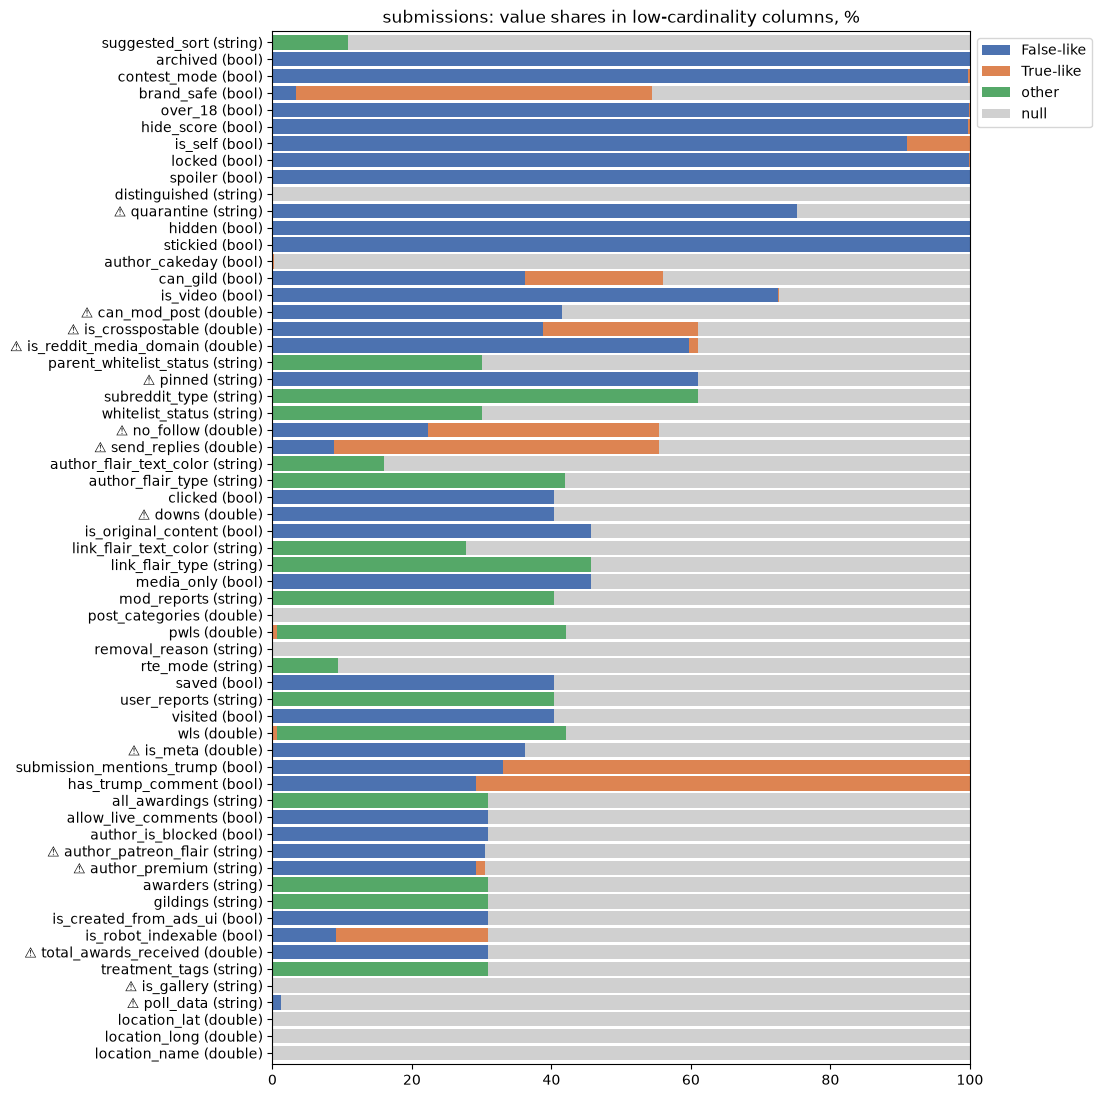

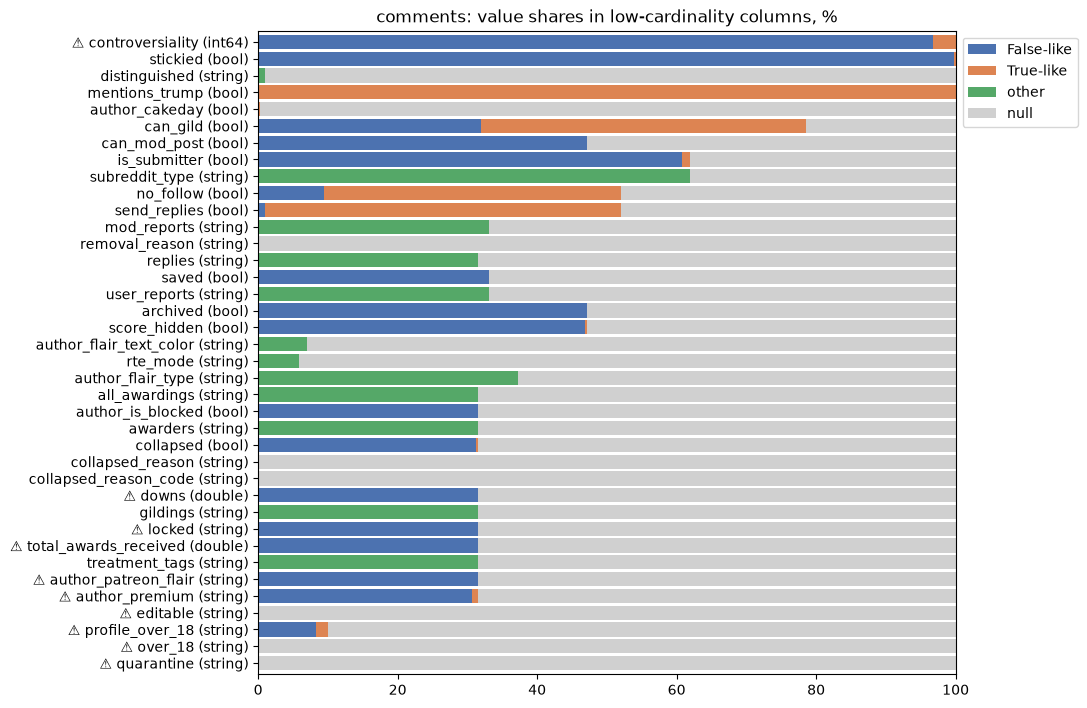

In [ ]:
FALSE_LIKE, TRUE_LIKE = {"False", "false", "0", "0.0"}, {"True", "true", "1", "1.0"}
COLORS = {"False-like": "#4c72b0", "True-like": "#dd8452", "other": "#55a868", "null": "#d0d0d0"}


def kind(v):
    return "null" if v is None else "False-like" if str(v) in FALSE_LIKE else "True-like" if str(v) in TRUE_LIKE else "other"


def value_shares(name, max_mb=100, max_distinct=5):
    md = files[name].metadata
    rows = {}
    for j in range(md.num_columns):
        c = md.schema.column(j).name
        # skip heavy text columns (body, preview, permalink) — never low-cardinality anyway
        if sum(md.row_group(i).column(j).total_uncompressed_size for i in range(md.num_row_groups)) > max_mb * 1024**2:
            continue
        col = files[name].read(columns=[c])[c]
        if pa.types.is_null(col.type) or pc.count_distinct(col).as_py() > max_distinct:
            continue
        vc = pc.value_counts(col).to_pylist()
        s = pd.Series([v["counts"] for v in vc], index=[kind(v["values"]) for v in vc]).groupby(level=0).sum()
        warn = "!! " if not pa.types.is_boolean(col.type) and set(s.index) - {"null"} and set(s.index) - {"null"} <= {"False-like", "True-like"} else ""
        rows[f"{warn}{c} ({col.type})"] = 100 * s / s.sum()
    return pd.DataFrame(rows).T.reindex(columns=list(COLORS)).fillna(0)


for k in files:
    shares = value_shares(k).iloc[::-1]  # barh draws bottom-up; keep schema order top-down
    shares.plot.barh(stacked=True, color=COLORS, width=0.85, figsize=(9, 0.22 * len(shares)), xlim=(0, 100),
                     title=f"{k}: value shares in low-cardinality columns, %").legend(loc="upper left", bbox_to_anchor=(1, 1))

Takeaways for preprocessing:
- **Bools stored as string / float** (same NaN-promotion as quarantine/pinned) → cast to pandas `boolean`:
  submissions `can_mod_post`, `is_crosspostable`, `is_reddit_media_domain`, `no_follow`, `send_replies`, `is_meta` (double 0/1), `author_premium`, `author_patreon_flair`, `is_gallery`, `poll_data` (string);
  comments `locked`, `author_premium`, `author_patreon_flair`, `editable`, `profile_over_18`, `over_18`, `quarantine` (string).
- **Constant columns** (one value + nulls) → drop: e.g. `archived`, `hidden`, `downs`, `saved`, `clicked`, `visited`, `mod_reports`, `user_reports`, `gildings`, `awarders`, `all_awardings`, `treatment_tags`, `total_awards_received`, `author_is_blocked`, `quarantine`, `pinned`; comments `mentions_trump` is always True by construction.
- **`edited`** (not listed, too many values): `'False'` or an edit timestamp as string → split into `is_edited` bool + `edited_utc` int.